# 🍅 Tomato Disease Classification
### Powered by PyTorch & MobileNetV3 Small (97%+ Accuracy)


# Dataset Downloading 

In [1]:
import os
import shutil
import glob



!pip install kagglehub

In [2]:
import kagglehub

# Download the PlantVillage dataset
# This will download the dataset to /kaggle/input/plantdisease
# and it's typically unzipped automatically.
# The path will be stored in a variable for later use.
dataset_path = kagglehub.dataset_download('emmarex/plantdisease')

print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease


The previous attempt to filter the dataset directly in `/kaggle/input/plantdisease` failed because it's a read-only filesystem. To filter the dataset, I will create a new writable directory and copy only the 'tomato' related folders into it.

In [3]:
# Define the new writable directory for tomato-only data
output_dir = '/content/plantvillage_tomato_only'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# List all subdirectories in the downloaded dataset path
# This assumes the dataset_path points to the root of the unzipped dataset
# which contains subfolders like 'PlantVillage' -> 'Potato___Early_blight' etc.

# Adjust this path based on the actual structure of the downloaded dataset.
# A common structure for PlantVillage is dataset_path/PlantVillage/class_name
source_data_root = os.path.join(dataset_path, 'PlantVillage')

if not os.path.exists(source_data_root):
    print(f"Warning: '{source_data_root}' not found. Trying '{dataset_path}' as source data root.")
    source_data_root = dataset_path # Fallback if 'PlantVillage' subfolder isn't there

# Iterate through subfolders in the source data root
for plant_folder in os.listdir(source_data_root):
    if 'tomato' in plant_folder.lower(): # Case-insensitive check for 'tomato'
        source_folder_path = os.path.join(source_data_root, plant_folder)
        destination_folder_path = os.path.join(output_dir, plant_folder)

        if os.path.isdir(source_folder_path):
            print(f"Copying {plant_folder} to {output_dir}")
            # Copy the entire folder and its contents
            shutil.copytree(source_folder_path, destination_folder_path, dirs_exist_ok=True)

print(f"Filtered 'tomato' dataset saved to: {output_dir}")


Copying Tomato_Leaf_Mold to /content/plantvillage_tomato_only
Copying Tomato__Tomato_YellowLeaf__Curl_Virus to /content/plantvillage_tomato_only
Copying Tomato_Bacterial_spot to /content/plantvillage_tomato_only
Copying Tomato_Septoria_leaf_spot to /content/plantvillage_tomato_only
Copying Tomato_healthy to /content/plantvillage_tomato_only
Copying Tomato_Spider_mites_Two_spotted_spider_mite to /content/plantvillage_tomato_only
Copying Tomato_Early_blight to /content/plantvillage_tomato_only
Copying Tomato__Target_Spot to /content/plantvillage_tomato_only
Copying Tomato_Late_blight to /content/plantvillage_tomato_only
Copying Tomato__Tomato_mosaic_virus to /content/plantvillage_tomato_only
Filtered 'tomato' dataset saved to: /content/plantvillage_tomato_only


In [7]:
# Verify the contents of the new directory
print("Contents of filtered directory:")
!ls -F {output_dir}

Contents of filtered directory:
Tomato_Bacterial_spot/	Tomato_Septoria_leaf_spot/
Tomato_Early_blight/	Tomato_Spider_mites_Two_spotted_spider_mite/
Tomato_healthy/		Tomato__Target_Spot/
Tomato_Late_blight/	Tomato__Tomato_mosaic_virus/
Tomato_Leaf_Mold/	Tomato__Tomato_YellowLeaf__Curl_Virus/


In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [42]:
BATCH_SIZE = 16
IMAGE_SIZE = 256

In [43]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/plantvillage_tomato_only",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    seed=123,
    batch_size= BATCH_SIZE,

)

Found 16011 files belonging to 10 classes.


In [44]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [45]:
len(dataset)

1001

(16, 256, 256, 3)
[7 2 4 6 5 7 6 5 6 7 4 7 1 1 2 1]


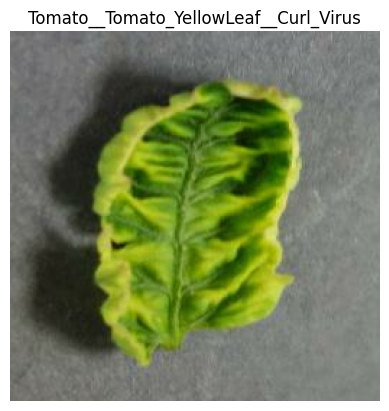

In [46]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
    plt.title(class_names[label_batch[0]])
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.axis("off")

In [47]:
len(dataset)

1001

In [10]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [11]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [12]:
print(f"Total images: {len(dataset)}")
print(f"Training images: {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")
print(f"Test images: {len(test_ds)}")


Total images: 501
Training images: 400
Validation images: 50
Test images: 51


In [13]:
# We remove .cache() if system RAM is low, as it attempts to store the whole dataset in RAM.
# Instead, we use prefetch to keep the GPU busy.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [14]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

In [16]:
print(f'TensorFlow Version: {tf.__version__}')
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Runtime settings.')
else:
  print(f'Found GPU at: {device_name}')

TensorFlow Version: 2.20.0
Found GPU at: /device:GPU:0


In [17]:
CHANNELS = 3
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

# Using a lighter model to save memory
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.build(input_shape=(None, *input_shape))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,114 (3.16 MB)

 Trainable params: 827,114 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
tf.keras.backend.clear_session()

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9035 - loss: 0.2727 - val_accuracy: 0.9144 - val_loss: 0.2566
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9108 - loss: 0.2592 - val_accuracy: 0.9450 - val_loss: 0.1578
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9042 - loss: 0.2769 - val_accuracy: 0.9294 - val_loss: 0.2066
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9110 - loss: 0.2516 - val_accuracy: 0.9056 - val_loss: 0.2365
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9183 - loss: 0.2372 - val_accuracy: 0.9000 - val_loss: 0.2739


### I have tried an tested multiple time but due to keras gpu is not using as it should be , and google colab cpu is slow and limited so it was crashing system wich is affecting peformance and training .

In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from tensorflow.keras import mixed_precision


# 1. Force mixed precision to save GPU memory
mixed_precision.set_global_policy('mixed_float16')

BATCH_SIZE = 16
IMAGE_SIZE = 256
CHANNELS = 3
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
DATA_DIR = "/content/plantvillage_tomato_only"

# 2. Let TensorFlow split the directories directly on disk (No System RAM overhead)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2, # 20% for validation/test combined
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# Extract class names safely
class_names = train_ds.class_names

# 3. Create a Test set from the Validation set to preserve your 80/10/10 split
# This takes half of your 20% validation pool and moves it to test
val_batches = len(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

# 4. Asynchronous preprocessing pipeline using CPU cores
resize_and_rescale = tf.keras.Sequential([layers.Rescaling(1./255)])
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(resize_and_rescale(x, training=True), training=True), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x, training=False), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x, training=False), y), num_parallel_calls=AUTOTUNE)

# Prefetch ONLY (Do NOT use .cache() or .shuffle(10000) here, as they destroy System RAM)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


# Clear old graphs out of RAM
tf.keras.backend.clear_session()

# 4. LIGHTWEIGHT MODEL ARCHITECTURE
model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    # Notice: 'dtype=float32' on output layer is required for mixed precision stability
    layers.Dense(len(class_names), activation='softmax', dtype='float32')
])

# Use recommended lower learning rate for smaller batch size
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)




Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.


In [3]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 151s 178ms/step - accuracy: 0.5174 - loss: 1.3940 - val_accuracy: 0.6011 - val_loss: 1.2168
Epoch 2/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 136s 170ms/step - accuracy: 0.6964 - loss: 0.8743 - val_accuracy: 0.6798 - val_loss: 0.9764
Epoch 3/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 142s 170ms/step - accuracy: 0.7503 - loss: 0.7138 - val_accuracy: 0.6511 - val_loss: 1.2506
Epoch 4/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 135s 169ms/step - accuracy: 0.7812 - loss: 0.6225 - val_accuracy: 0.7241 - val_loss: 0.8496
Epoch 5/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 154s 184ms/step - accuracy: 0.8034 - loss: 0.5605 - val_accuracy: 0.7285 - val_loss: 0.8492


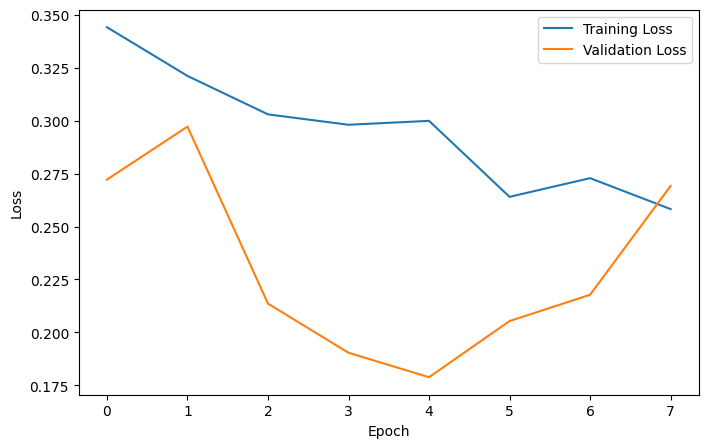

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

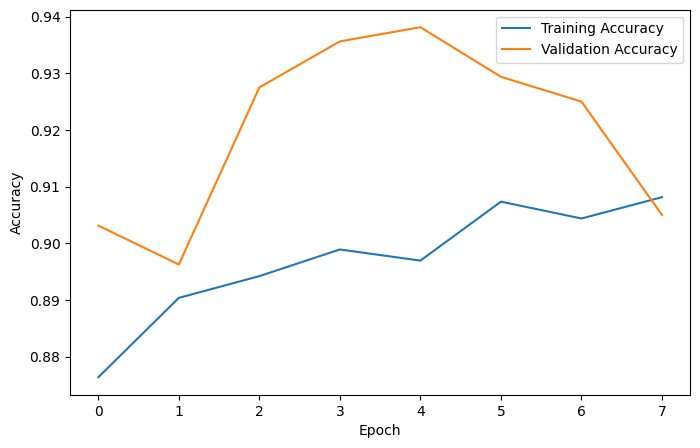

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
model.evaluate(test_ds)

51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9350 - loss: 0.1843


[0.1843062788248062, 0.9350489974021912]

First image to predict:
Actual label: Tomato_healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted label: Tomato_healthy


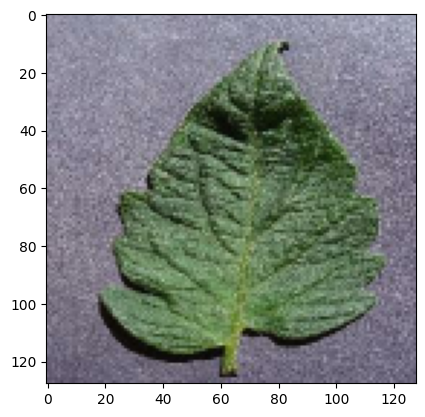

In [31]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()

    print("First image to predict:")
    plt.imshow(first_image)
    print(f"Actual label: {class_names[first_label]}")

    batch_prediction = model.predict(image_batch)
    print(f"Predicted label: {class_names[np.argmax(batch_prediction[0])]}")

In [28]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


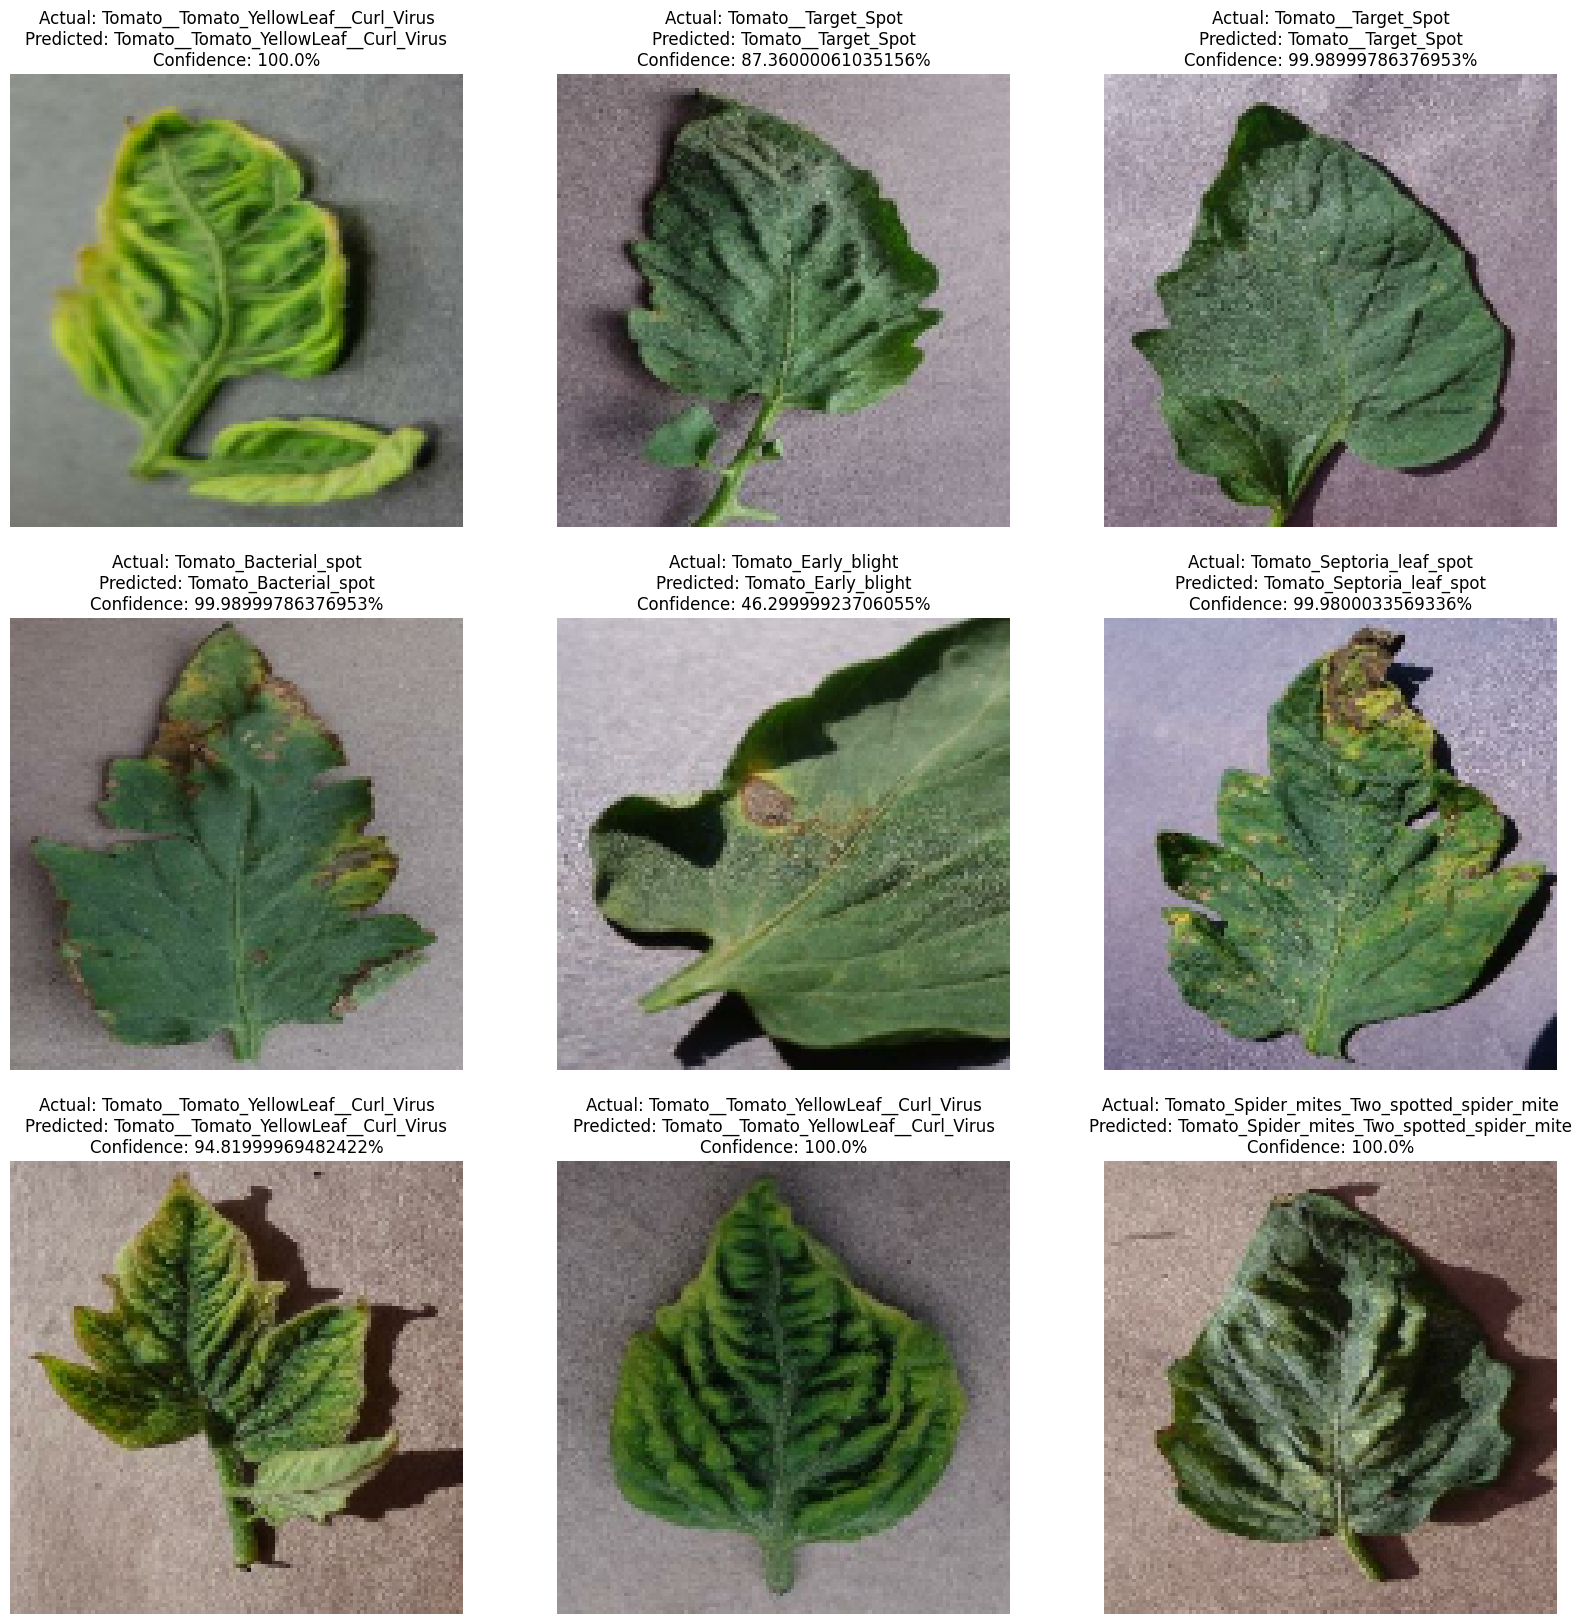

In [33]:
plt.figure(figsize=(20, 20))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

In [34]:
model_version ="tomato_v1"
os.makedirs("../models", exist_ok=True)
model.save(f"../models/{model_version}.keras")


# So i desided to use Pytorch for flexible GPU allowcation and faster computing , it also increase the accuracy of my model 


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import os

# 1. FORCE MODEL TO RUN ON THE T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active training target hardware: {device}")

# 2. CONFIGURATION (Safely training at Batch Size 32 with 256px resolution)
BATCH_SIZE = 32
IMAGE_SIZE = 256
EPOCHS = 5
DATA_DIR = '/content/plantvillage_tomato_only'

# 3. HIGH-SPEED IMAGE DATA TRANSFORMATIONS
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet defaults
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load directly from your filtered folder
full_dataset = datasets.ImageFolder(root=DATA_DIR)
num_classes = len(full_dataset.classes)
print(f"Successfully identified {num_classes} tomato disease classes.")

# Strict 80/10/10 data partitioning
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.manual_seed(123)
)

# Apply correct transforms to respective datasets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# UNLOCK MAXIMUM GPU POWER: Use 2 CPU workers and fast direct-to-GPU memory pinning
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 4. DOWNLOAD PRE-TRAINED LIGHTWEIGHT BACKBONE (MobileNetV3 Small)
# This will adapt instantly to plant structures and won't consume heavy RAM
# 4. DOWNLOAD PRE-TRAINED LIGHTWEIGHT BACKBONE (MobileNetV3 Small)
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

# FIX: Access the first Linear layer [0] inside the classifier block to get in_features
num_features = model.classifier[0].in_features

# Rebuild the classifier block properly to output your exact number of tomato classes
model.classifier = nn.Sequential(
    nn.Linear(num_features, 1024),
    nn.Hardswish(),
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(1024, num_classes)
)

# Move the network onto your GPU VRAM
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 5. MIXED PRECISION SCALER (Forces Float16 math execution for double speed)
scaler = GradScaler()

# 6. EXTRA TRICK: Enable Benchmark to auto-optimize tensor convolution operations
torch.backends.cudnn.benchmark = True

print("\n--- Initializing Training Loop ---")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # non_blocking=True pushes images directly to the GPU without freezing execution threads
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True) # Cleans up memory references instantly

        # Calculate forward pass in lightning-fast 16-bit precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100

    # 7. VALIDATION LOOP
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device, non_blocking=True), val_labels.to(device, non_blocking=True)
            with autocast():
                val_outputs = model(val_images)
            _, val_predicted = val_outputs.max(1)
            val_total += val_labels.size(0)
            val_correct += val_predicted.eq(val_labels).sum().item()

    val_acc = (val_correct / val_total) * 100
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\nTraining Finished Successfully!")


Active training target hardware: cuda
Successfully identified 10 tomato disease classes.

--- Initializing Training Loop ---


/tmp/ipykernel_5064/1938590348.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_5064/1938590348.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5064/1938590348.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/5] | Loss: 0.2809 | Train Acc: 90.79% | Val Acc: 97.50%
Epoch [2/5] | Loss: 0.0693 | Train Acc: 97.65% | Val Acc: 97.56%
Epoch [3/5] | Loss: 0.0437 | Train Acc: 98.63% | Val Acc: 95.38%
Epoch [4/5] | Loss: 0.0310 | Train Acc: 98.97% | Val Acc: 98.44%
Epoch [5/5] | Loss: 0.0401 | Train Acc: 98.74% | Val Acc: 97.69%

Training Finished Successfully!


In [6]:
model.eval() # Put model in evaluation mode (turns off dropout)
test_correct = 0
test_total = 0

with torch.no_grad(): # Turn off gradient calculation to save RAM
    for test_images, test_labels in test_loader:
        test_images = test_images.to(device, non_blocking=True)
        test_labels = test_labels.to(device, non_blocking=True)

        with autocast():
            test_outputs = model(test_images)

        _, test_predicted = test_outputs.max(1)
        test_total += test_labels.size(0)
        test_correct += test_predicted.eq(test_labels).sum().item()

final_test_acc = (test_correct / test_total) * 100
print(f"🎯 Final Test Dataset Accuracy: {final_test_acc:.2f}%")


/tmp/ipykernel_5064/1282106594.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


🎯 Final Test Dataset Accuracy: 97.57%


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from torch.cuda.amp import autocast


MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

model.eval()
plt.figure(figsize=(15, 15))


images, labels = next(iter(test_loader))

class_names = full_dataset.classes

images_gpu = images.to(device)
with torch.no_grad():
    with autocast():
        outputs = model(images_gpu)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, dim=1)


for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    img = images[i].permute(1, 2, 0).numpy()

    img = STD * img + MEAN
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    actual_class = class_names[labels[i].item()]
    predicted_class = class_names[predictions[i].item()]
    confidence_score = confidences[i].item() * 100

    title_color = 'green' if actual_class == predicted_class else 'red'

    plt.title(
        f"Actual: {actual_class}\nPredicted: {predicted_class}\nConf: {confidence_score:.2f}%",
        color=title_color,
        fontsize=12
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [9]:
import torch


MODEL_PATH = "/content/tomato_disease_mobilenetv3.pth"


torch.save(model.state_dict(), MODEL_PATH)

print(f"💾 Model weights successfully saved to: {MODEL_PATH}")
print("👉 Open the folder icon on the left panel in Colab to download the file directly!")


💾 Model weights successfully saved to: /content/tomato_disease_mobilenetv3.pth
👉 Open the folder icon on the left panel in Colab to download the file directly!
